In [1]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"


# ب

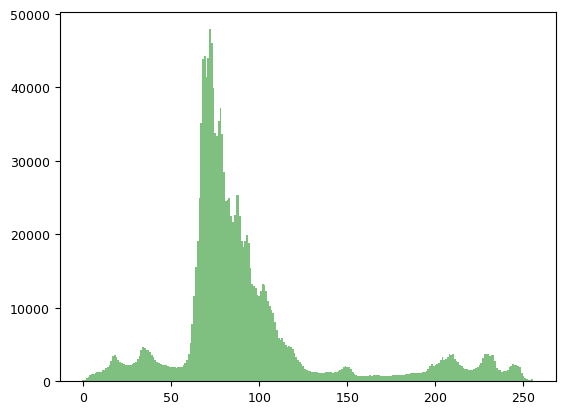

optimal threshold 142


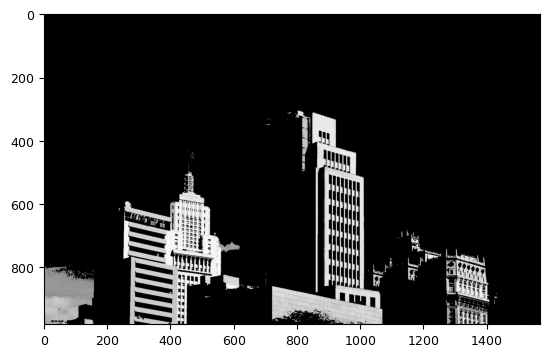

True

In [9]:
import math
import numpy as np
import cv2
from matplotlib import pyplot as plt

# Initializing a dictionary to store threshold values
threshold_values = {}

# Initializing a list to store histogram values
h = [1]

# Function to calculate and display the histogram of an image
def Hist(img):
    row, col = img.shape 
    y = np.zeros(256)
    for i in range(0, row):
        for j in range(0, col):
            y[img[i, j]] += 1
    x = np.arange(0, 256)
    plt.bar(x, y, color='g', width=1, align='center', alpha=0.5)
    plt.show()
    return y

# Function to regenerate the image based on a given threshold
def regenerate_img(img, threshold):
    row, col = img.shape 
    y = np.zeros((row, col))
    for i in range(0, row):
        for j in range(0, col):
            if img[i, j] >= threshold:
                y[i, j] = img[i, j]
            else:
                y[i, j] = 0
    return y

# Function to count the total number of pixels in a histogram
def countPixel(h):
    cnt = 0
    for i in range(0, len(h)):
        if h[i] > 0:
            cnt += h[i]
    return cnt

# Function to calculate the sum of pixel intensities in a histogram within a specified range
def weight(s, e):
    w = 0
    for i in range(s, e):
        w += h[i]
    return w

# Function to calculate the mean of pixel intensities in a histogram within a specified range
def mean(s, e):
    m = 0
    w = weight(s, e)
    for i in range(s, e):
        m += h[i] * i
    return m / float(w)

# Function to calculate the variance of pixel intensities in a histogram within a specified range
def variance(s, e):
    v = 0
    m = mean(s, e)
    w = weight(s, e)
    for i in range(s, e):
        v += ((i - m) ** 2) * h[i]
    v /= w
    return v

# Function to determine the optimal threshold using Otsu's method
def threshold(h):
    cnt = countPixel(h)
    for i in range(1, len(h)):
        vb = variance(0, i)
        wb = weight(0, i) / float(cnt)
        mb = mean(0, i)

        vf = variance(i, len(h))
        wf = weight(i, len(h)) / float(cnt)
        mf = mean(i, len(h))

        V2w = wb * (vb) + wf * (vf)

        # Check for NaN to avoid errors
        if not math.isnan(V2w):
            threshold_values[i] = V2w

# Function to find the optimal threshold value
def get_optimal_threshold():
    min_V2w = min(threshold_values.values())
    optimal_threshold = [k for k, v in threshold_values.items() if v == min_V2w]
    print('optimal threshold', optimal_threshold[0])
    return optimal_threshold[0]

# Path to the image file
image_path = 'buildings.jpeg'

# Reading the image using OpenCV in grayscale mode
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

# Displaying the original image histogram
h = Hist(img)

# Calculating the optimal threshold and regenerate the image
threshold(h)
op_thresh = get_optimal_threshold()
res = regenerate_img(img, op_thresh)

# Displaying the regenerated image
plt.imshow(res, cmap='gray')
plt.show()

# Saving the regenerated image using OpenCV
cv2.imwrite("buildings_otsu.jpeg", res)


# ج

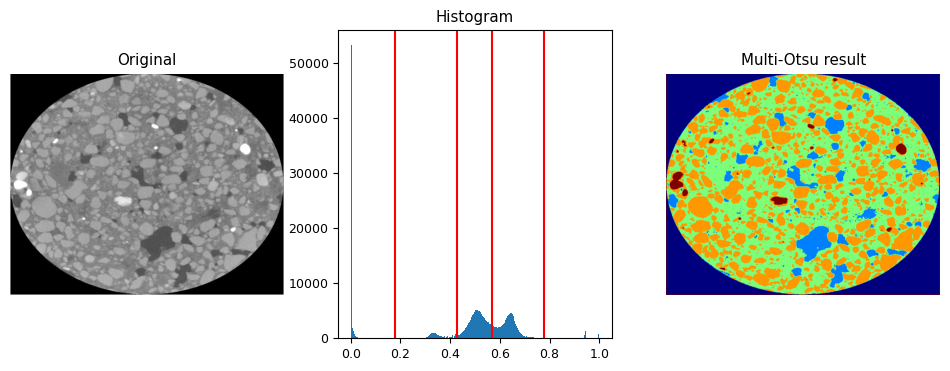

In [10]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
from skimage import io, color
from skimage.filters import threshold_multiotsu
import cv2

# Setting the font size for all plots
matplotlib.rcParams['font.size'] = 9

# Loading the input image.
image = io.imread('soil.jpg')

# Converting the image to grayscale 
if image.ndim == 3:
    image = color.rgb2gray(image)

# Applying multi-Otsu threshold for 5 classes
thresholds = threshold_multiotsu(image, classes=5)

# Using the threshold values, 5 regions will be generated 
regions = np.digitize(image, bins=thresholds)

fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(12, 4))

# Plotting the original image
ax[0].imshow(image, cmap='gray')
ax[0].set_title('Original')
ax[0].axis('off')

# Plotting the histogram and the thresholds obtained from multi-Otsu
ax[1].hist(image.ravel(), bins=255)
ax[1].set_title('Histogram')
for thresh in thresholds:
    ax[1].axvline(thresh, color='r')

# Plotting the Multi Otsu result with 'jet' colormap
cmap_jet = plt.get_cmap('jet', 5)
ax[2].imshow(cmap_jet(regions), cmap='jet')
ax[2].set_title('Multi-Otsu result')
ax[2].axis('off')

plt.subplots_adjust()

# Saving the Multi-Otsu result with 'jet' colormap
cv2.imwrite('soil_otsu.jpg', (cmap_jet(regions) * 255).astype(np.uint8))

plt.show()
